In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""
Unsupervised K-Means Clustering on Sensor Data
================================================
Dataset: 1600 breakdowns × 20 sensors (values between -1 and +1)
Goal: Find natural groupings in the data without using any labels.
"""

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --------------------------------------------------
# Step 1: Load the data
# --------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/data_sensors.csv')

# Use only the 20 sensor columns (drop the Label column)
sensor_cols = [f'Sensor {i}' for i in range(20)]
X = df[sensor_cols].values

print(f"Dataset shape: {X.shape}")
print(f"(1600 breakdowns, 20 sensor features)\n")

Dataset shape: (1600, 20)
(1600 breakdowns, 20 sensor features)



In [ ]:
# --------------------------------------------------
# Step 2: Scale the data (best practice for K-Means)
# --------------------------------------------------
# Even though values are already between -1 and +1, StandardScaler
# ensures each sensor has mean=0 and std=1, giving equal importance.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# --------------------------------------------------
# Step 3: Find the optimal number of clusters (Elbow + Silhouette)
# --------------------------------------------------
k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Finding optimal k...")
print("-" * 40)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    print(f"k={k:2d} | Inertia: {kmeans.inertia_:10.2f} | Silhouette Score: {sil_score:.4f}")

print("-" * 40)
best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nBest k by Silhouette Score: {best_k}")

Finding optimal k...
----------------------------------------
k= 2 | Inertia:   30631.53 | Silhouette Score: 0.0428
k= 3 | Inertia:   29816.82 | Silhouette Score: 0.0356
k= 4 | Inertia:   29128.17 | Silhouette Score: 0.0357
k= 5 | Inertia:   28589.80 | Silhouette Score: 0.0348
k= 6 | Inertia:   28099.16 | Silhouette Score: 0.0353
k= 7 | Inertia:   27651.72 | Silhouette Score: 0.0353
k= 8 | Inertia:   27297.25 | Silhouette Score: 0.0361
k= 9 | Inertia:   26964.62 | Silhouette Score: 0.0368
k=10 | Inertia:   26622.60 | Silhouette Score: 0.0372
----------------------------------------

Best k by Silhouette Score: 2


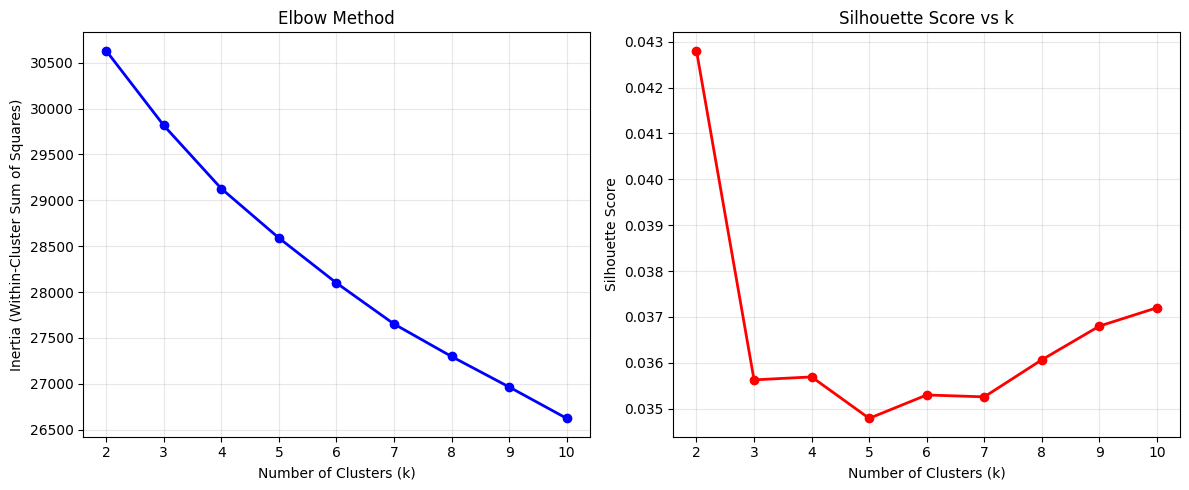

In [ ]:
# --------------------------------------------------
# Step 4: Plot Elbow and Silhouette curves
# --------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow plot
ax1.plot(k_range, inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# Step 5: Run final K-Means with the best k
# --------------------------------------------------
print(f"\nRunning final K-Means with k={best_k}...")
kmeans_final = KMeans(
    n_clusters=best_k,
    init='k-means++',   # Smart initialization (avoids bad starting points)
    n_init=10,          # Run 10 times with different seeds, pick best
    max_iter=300,       # Max iterations per run
    random_state=42     # Reproducibility
)
cluster_labels = kmeans_final.fit_predict(X_scaled)


Running final K-Means with k=2...


In [ ]:
# --------------------------------------------------
# Step 6: Analyze the clusters
# --------------------------------------------------
df['Cluster'] = cluster_labels

print(f"\nCluster Distribution:")
print("-" * 30)
for c in range(best_k):
    count = (cluster_labels == c).sum()
    print(f"  Cluster {c}: {count} breakdowns")


Cluster Distribution:
------------------------------
  Cluster 0: 801 breakdowns
  Cluster 1: 799 breakdowns


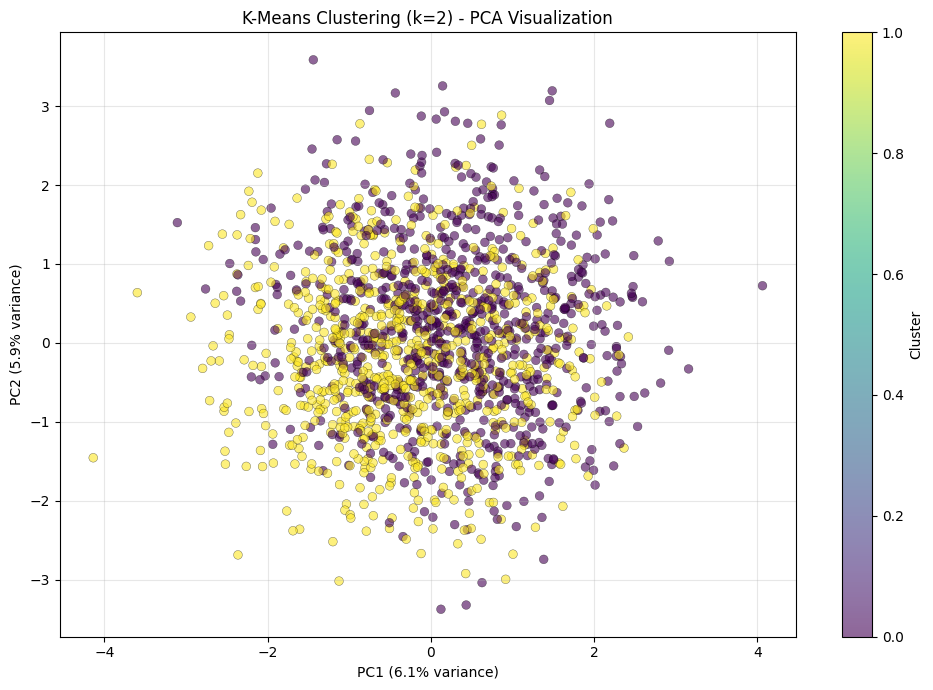

In [ ]:
# --------------------------------------------------
# Step 7: Visualize clusters using PCA (2D projection)
# --------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis',
                      alpha=0.6, edgecolors='k', linewidth=0.3, s=40)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'K-Means Clustering (k={best_k}) - PCA Visualization')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# Step 8: Save results to CSV
# --------------------------------------------------
output_df = df[sensor_cols + ['Cluster']].copy()
output_df.to_csv('/content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/results/kmeans_results.csv', index=False)
print("Saved: kmeans_results.csv")

print("\nDone! Check the plots and CSV for results.")

Saved: kmeans_results.csv

Done! Check the plots and CSV for results.


# The End